# **1. Necessary Imports**

In [52]:
# Numerical arrays
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold

# Data Preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

# Model evaluation
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                            roc_curve, ConfusionMatrixDisplay, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score)

# Model optimization
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier

from google.colab import drive
drive.mount('/content/drive')

# Store the model
import joblib

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2. Data Loading and Preprocessing**

In [53]:
# Reading the data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer-telco-churn/data/cleaned/cleaned_data.csv')

In [54]:
# Drop unnecessary columms and encode target variable
df = df.drop(["customerID", "gender"], axis=1)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == "Yes" else 0)

In [55]:
# Seperate independent and dependent variables
X = df.drop('Churn', axis=1)
y = df['Churn']

In [56]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [57]:
# Get categorical (nominal + ordinal), numerical features for later preprocessing
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns.drop('Contract')  # Exclude the ordinal column
ordinal_feature = ['Contract']  # Contracts get better from Month-to-month to One year to Two year

# **3. Create Preprocessing Pipeline**

In [58]:
# Categorical (excluding ordinal)
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # convert each column into seperate binary columns
])

# Ordinal feature
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[
        ['Month-to-month', 'One year', 'Two year']  # Month-to-month < One year < Two year
    ]))
])

# Create the preprocessor
preprocessor = ColumnTransformer(   # combine all preprocessing for mixed data types
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_feature)
    ],
    remainder='passthrough' # keep the numerical features as they are
)

In [59]:
def clean_feature_names(feature_names):
    """
    Clean feature names by removing transformer prefixes
    """
    cleaned_names = []

    for name in feature_names:
        # Remove transformer prefixes
        if name.startswith('cat__'):
            name = name[5:]  # Remove 'cat__'
        elif name.startswith('ord__'):
            name = name[5:]  # Remove 'ord__'
        elif name.startswith('remainder__'):
            name = name[11:]  # Remove 'remainder__'

        # Replace underscores with spaces for better readability
        name = name.replace('_', ' ')

        # Capitalize each word
        name = ' '.join(word.capitalize() for word in name.split())

        cleaned_names.append(name)

    return cleaned_names

In [60]:
# Fit the preprocessor
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [61]:
# Get the feature names
feature_names_raw = preprocessor.get_feature_names_out()
feature_names = clean_feature_names(feature_names_raw)

# **4. Class Imbalance with Class Weights**

In [62]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

In [63]:
def predict_with_threshold(model, threshold=0.5):
  """
  Used to make predictions with a threshold value
  """
  y_prob = model.predict_proba(X_test)[:, 1]
  y_pred = (y_prob > threshold).astype(int)

  return (y_pred, y_prob)

# **5. Base Model Training**

In [64]:
# Create base model
base_tree = DecisionTreeClassifier(random_state=42,
                                   class_weight=class_weight_dict)

base_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: np.float64(0.6805991785455424),
                                     1: np.float64(1.8842809364548494)},
                       random_state=42)

In [65]:
# Make predictions
y_pred_base = base_tree.predict(X_test)
y_pred_proba_base = base_tree.predict_proba(X_test)[:, 1]

In [66]:
# Store base metrics
base_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall': recall_score(y_test, y_pred_base),
    'F1-Score': f1_score(y_test, y_pred_base),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_base)
}

In [67]:
def check_overfitting_underfitting(train_accuracy, test_accuracy):
  """
  Used to check if a model is overfitting or underfitting by
  plotting a graph
  """
  metrics = {
      'Dataset': ['Train', 'Test'],
      'Accuracy':
      [
          train_accuracy,
          test_accuracy
      ]
  }

  df_metrics = pd.DataFrame(metrics)

  # Plot
  fig = px.bar(df_metrics, x='Dataset', y='Accuracy', text='Accuracy',
              title='Train and Test Accuracies',
              color='Dataset')
  fig.show()

In [68]:
def plot_ks_chart(y_true, y_pred_proba, model_name):
  """
  Plots KS Chart for binary classification of churn
  """

  # Calculate KS Statistic
  fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
  ks_values = tpr - fpr
  ks_statistic = np.max(ks_values)
  ks_idx = np.argmax(ks_values)
  ks_threshold = thresholds[ks_idx]

  # Create dataframe for plotting
  df_ks = pd.DataFrame({
      'Thresholds': thresholds,
      'TPR': tpr,
      'FPR': fpr,
      'KS': ks_values
  })

  # Plot
  plt.figure(figsize=(10,6))
  sns.lineplot(x='Thresholds', y='TPR', data=df_ks, label='True Positive Rate (TPR)', color='blue')
  sns.lineplot(x='Thresholds', y='FPR', data=df_ks, label='False Positive Rate (FPR)', color='red')

  # Shade the KS region
  plt.fill_between(df_ks['Thresholds'], df_ks['TPR'], df_ks['FPR'],
                   where=(df_ks['TPR'] >= df_ks['FPR']),
                   color='gray', alpha=0.2, interpolate=True)

  # Makr KS point
  plt.scatter(ks_threshold, tpr[ks_idx], color='green', s=50, label=f'KS Point ({ks_statistic:.3f})')
  plt.scatter(ks_threshold, fpr[ks_idx], color='green', s=50)

  # Style the plot
  plt.title(f"KS Chart - {model_name}", fontsize=14)
  plt.xlabel("Thresholds")
  plt.ylabel("Cumulative Percentage")
  plt.xlim([0,1])
  plt.ylim([0,1])
  plt.grid(True)
  plt.legend()
  plt.show()

In [69]:
def evaluate(model_name, y_prob, y_pred, y_true):
  """
  Used to evaluate a model and plot a confusion matrix
  """
  print(f"Model: {model_name}")
  print(classification_report(y_true, y_pred, target_names=['No churn', 'Churn']))

  cm = confusion_matrix(y_true, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot()

# **6. Base Model Evaluation**

Model: Base Tree
              precision    recall  f1-score   support

    No churn       0.81      0.82      0.82      1035
       Churn       0.49      0.47      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.73      0.73      1409



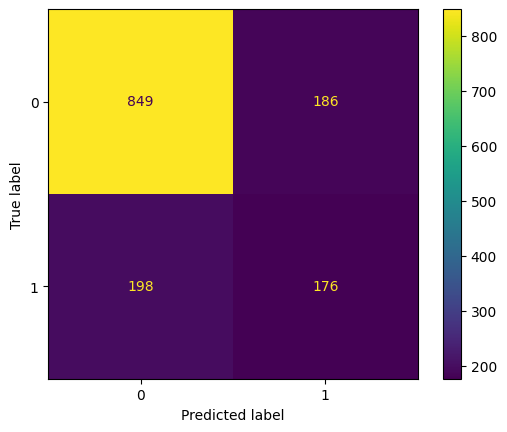

In [70]:
# evaluate base tree
evaluate("Base Tree", y_pred_proba_base, y_pred_base, y_test)

In [71]:
# Get the training and test accuracies and check for overfitting/underfitting
train_acc_base = base_tree.score(X_train, y_train)
test_acc_base = base_tree.score(X_test, y_test)
check_overfitting_underfitting(train_acc_base, test_acc_base)

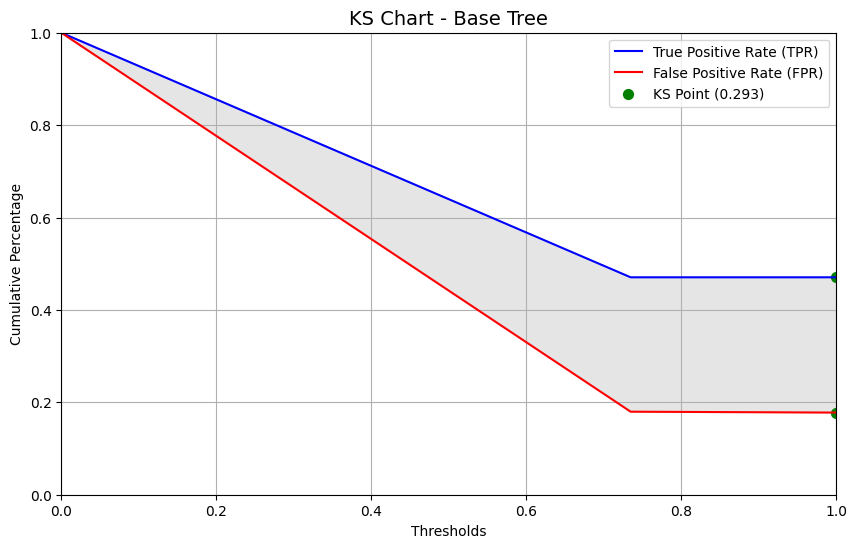

In [72]:
plot_ks_chart(y_test, y_pred_proba_base, "Base Tree")

In [73]:
def visualize_importances(model, feature_names, total_features=15):
  """
  Plots the feature importances for the decision tree in descending order
  """
  importances = model.feature_importances_

  # Create a dataframe
  feat_df = pd.DataFrame({
      'Feature': feature_names,
      'Importance': importances
  }).sort_values('Importance', ascending=False) # in descending order

  print(f"Top {total_features}:")
  top_feats = feat_df.head(total_features)  # Get the required amount of features

  top_feats_sorted = top_feats.sort_values(by='Importance', ascending=False)  # sort so the highest importance is at the front

  # Make a barplot
  fig = px.bar(
      top_feats_sorted,
      x='Feature',
      y='Importance',
      color='Importance',
      color_continuous_scale='viridis',
      title=f"Top {total_features} Feature Importances"
  )

  # Set the figure layout
  fig.update_layout(
      xaxis_title='Feature',
      yaxis_title='Importance',
      height=600
  )

  fig.show()

In [74]:
# Check how the base tree made the predictions
visualize_importances(base_tree, feature_names, 15)

Top 15:


# **7. Hyperparameter Tuning**

In [75]:
# Hyperparameters to tune
param_grid = {
    'max_depth': [None, 5, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4, 8, 10, 15],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.002, 0.003, 0.05, 0.1],  # Cost complexity pruning
    'max_leaf_nodes': [None, 50, 100, 200, 300]
}

In [76]:
# base model creation
base_model = DecisionTreeClassifier(random_state=42, class_weight=class_weight_dict)

In [77]:
# Cross validation for imbalanced datasets
stratified_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [78]:
# Perform random search
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=100, # Number of parameter combinations to try
    cv=stratified_cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [79]:
# Fit with the training data
random_search.fit(X_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=DecisionTreeClassifier(class_weight={0: np.float64(0.6805991785455424),
                                                                  1: np.float64(1.8842809364548494)},
                                                    random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'ccp_alpha': [0.0, 0.001, 0.005, 0.002,
                                                      0.003, 0.05, 0.1],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 5, 10, 15, 20, 25,
                                                      30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'max_leaf_nodes': [None, 50, 100, 200,
                                                           300],
                                        'min_samples_leaf': [1, 2, 4, 8, 10,
                                                             15],
                                        'min_samples_split': [2, 5, 10, 20,
                                                              30]},
                   random_state=42, scoring='f1', verbose=1)

In [80]:
# Show the best auc score and the best parameters
print("Best F1 Score:", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)

Best F1 Score: 0.6194050633512915
Best Parameters: {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_leaf_nodes': 50, 'max_features': None, 'max_depth': 20, 'criterion': 'gini', 'ccp_alpha': 0.001}


# **8. Best Model Training**

In [81]:
# train best model
best_tree = random_search.best_estimator_
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.001,
                       class_weight={0: np.float64(0.6805991785455424),
                                     1: np.float64(1.8842809364548494)},
                       max_depth=20, max_leaf_nodes=50, min_samples_split=20,
                       random_state=42)

In [82]:
# Predictions for the best tree
y_pred_best = best_tree.predict(X_test)
y_prob_best = best_tree.predict_proba(X_test)[:, 1]

# **9. Best Model Evaluation**

In [83]:
# Store the tuned tree metrics
tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best),
    'Recall': recall_score(y_test, y_pred_best),
    'F1-Score': f1_score(y_test, y_pred_best),
    'ROC-AUC': roc_auc_score(y_test, y_prob_best)
}

In [84]:
# Show the classification report
print(classification_report(y_test, y_pred_best, target_names=['No churn', 'Churn']))

              precision    recall  f1-score   support

    No churn       0.91      0.74      0.82      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



In [85]:
# Check for overfitting/underfitting
check_overfitting_underfitting(best_tree.score(X_train, y_train), best_tree.score(X_test, y_test))

# **10. Model Comparisons**

In [86]:
# Create a dataframe to store the models and the metrics
comparisons_df = pd.DataFrame({
    'Metric': list(base_metrics.keys()),
    'Base Model': [base_metrics[metric] for metric in base_metrics.keys()],
    'Tuned Model': [tuned_metrics[metric] for metric in tuned_metrics.keys()]
})

In [87]:
# Calculating improvement
comparisons_df['Improvement'] = comparisons_df['Tuned Model'] - comparisons_df['Base Model']
comparisons_df['Improvement (%)'] = (comparisons_df['Improvement'] / comparisons_df['Base Model']) * 100

In [88]:
print("Performance Comparison:\n")
comparisons_df

Performance Comparison:



,Metric,Base Model,Tuned Model,Improvement,Improvement (%)
0,Accuracy,0.727466,0.754436,0.026969,3.707317
1,Precision,0.486188,0.524823,0.038635,7.946486
2,Recall,0.470588,0.791444,0.320856,68.181818
3,F1-Score,0.478261,0.631130,0.152869,31.963559
4,ROC-AUC,0.645894,0.830528,0.184634,28.585827


In [89]:
# Plot comparisons
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

fig = go.Figure()

# Base model bars
fig.add_trace(go.Bar(
    x=comparisons_df['Metric'],
    y=comparisons_df['Base Model'],
    name='Base Model',
    marker_color="#3498db",
    text=[f"{v:.3f}" for v in comparisons_df['Base Model']],
    textposition="outside"
))

# Tuned model bars
fig.add_trace(go.Bar(
    x=comparisons_df['Metric'],
    y=comparisons_df['Tuned Model'],
    marker_color="#2ecc71",
    text=[f"{v:.3f}" for v in comparisons_df['Tuned Model']],
    textposition="outside",
    name='Tuned Model'
))

fig.update_layout(
  title = "Model Performance Comparison (Base vs Tuned)",
  yaxis_title='Score',
  barmode='group',
  plot_bgcolor='white',
  font=dict(size=12),
  bargroupgap=0.15,
  bargap=0.20,
  xaxis=dict(showgrid=True, gridcolor='lightgray'),
  yaxis=dict(showgrid=True, gridcolor='lightgray'),
)

fig.show()

In [90]:
# Plot ROC and PR Curves
fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_base)
roc_auc_base = roc_auc_score(y_test, y_pred_proba_base)

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_best)
roc_auc_tuned = roc_auc_score(y_test, y_prob_best)

precision_base, recall_base, _ = precision_recall_curve(y_test, y_pred_base)
precision_tuned, recall_tuned, _ = precision_recall_curve(y_test, y_prob_best)

In [91]:
# ROC Curve for base tree vs tuned tree
fig_roc = go.Figure()

# Base tree
fig_roc.add_trace(go.Scatter(
    x=fpr_base,
    y=tpr_base,
    mode='lines',
    name=f"Base Model AUC = {roc_auc_base:.3f}",
    line=dict(width=2, color="#3498db")
))

# Tuned tree
fig_roc.add_trace(go.Scatter(
    x=fpr_tuned,
    y=tpr_tuned,
    mode='lines',
    name=f"Tuned Model AUC = {roc_auc_tuned:.3f}",
    line=dict(width=2, color="#2ecc71")
))

# Random classifier
fig_roc.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Random Guess',
    line=dict(width=1, color='grey', dash='dash')
))

fig_roc.update_layout(
    title='ROC Curve Comparison (Base vs Tuned)',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray'),
    font=dict(size=12)
)


In [92]:
# Precision recall curve for the base tree and tuned tree
fig_pr = go.Figure()

# Base tree
fig_pr.add_trace(go.Scatter(
    x=recall_base,
    y=precision_base,
    mode='lines',
    name='Base Model',
    line=dict(width=2, color='#3498db')
))

# Tuned tree
fig_pr.add_trace(go.Scatter(
    x=recall_tuned,
    y=precision_tuned,
    mode='lines',
    name='Tuned Model',
    line=dict(width=2, color='#2ecc71')
))

# Set the figure layout
fig_pr.update_layout(
    title='Precision-Recall Curve Comparison (Base vs Tuned)',
    xaxis_title='Recall',
    yaxis_title='Precision',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'), # grid lines
    yaxis=dict(showgrid=True, gridcolor='lightgray'),
    font=dict(size=12)
)

fig_pr.show()

Model: Base Tree
              precision    recall  f1-score   support

    No churn       0.81      0.82      0.82      1035
       Churn       0.49      0.47      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.73      0.73      1409



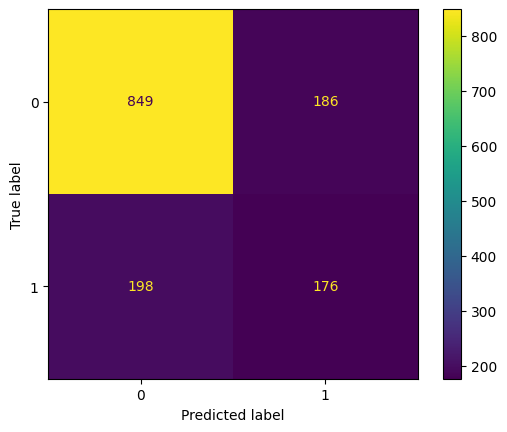

In [93]:
# Evaluate the base tree
evaluate("Base Tree", y_pred_proba_base, y_pred_base, y_test)

Model: Best Tree
              precision    recall  f1-score   support

    No churn       0.91      0.74      0.82      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



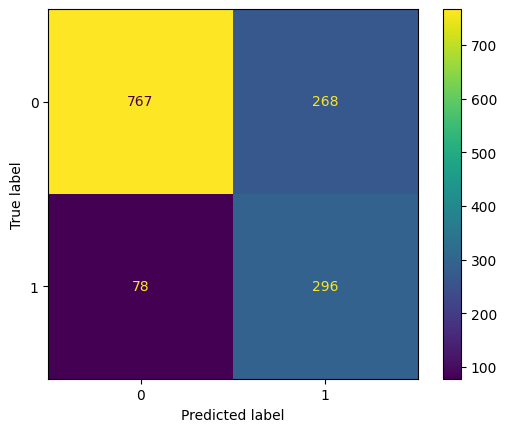

In [94]:
# Evaluate the best tree
evaluate("Best Tree", y_prob_best, y_pred_best, y_test)

# **11. Feature Importances and KS Charts**

In [95]:
# Feature importances for the base tree
print("Base tree feature importance:\n")
visualize_importances(base_tree, feature_names, 15)

Base tree feature importance:

Top 15:


In [96]:
print("Best tree importances:\n")
visualize_importances(best_tree, feature_names, 15)

Best tree importances:

Top 15:


In [97]:
y_best_threshold_pred_labels, y_best_threshold_proba = predict_with_threshold(best_tree, 0.4)

print(classification_report(y_test, y_best_threshold_pred_labels))

              precision    recall  f1-score   support

           0       0.93      0.61      0.74      1035
           1       0.45      0.87      0.59       374

    accuracy                           0.68      1409
   macro avg       0.69      0.74      0.67      1409
weighted avg       0.80      0.68      0.70      1409



In [98]:
y_best_threshold_pred_labels, y_best_threshold_proba = predict_with_threshold(best_tree, 0.45)

print(classification_report(y_test, y_best_threshold_pred_labels))

              precision    recall  f1-score   support

           0       0.91      0.69      0.78      1035
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409



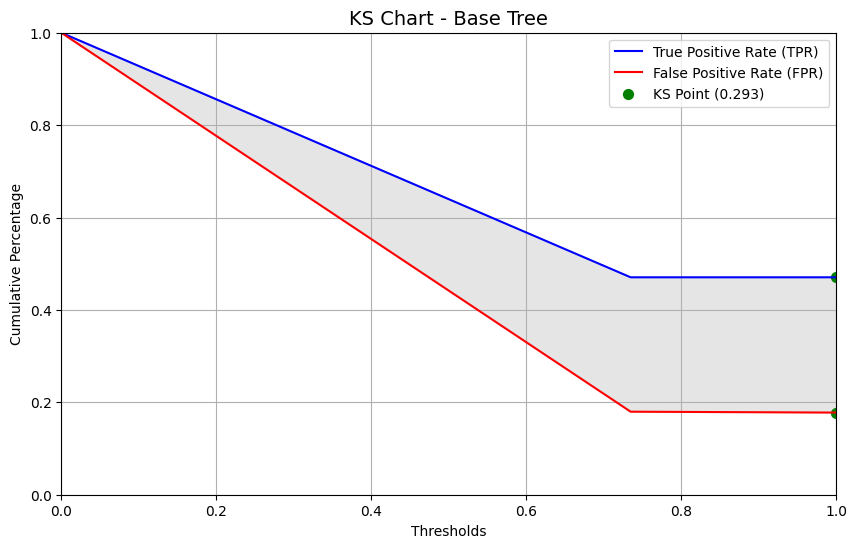

In [99]:
plot_ks_chart(y_test, y_pred_proba_base, "Base Tree")

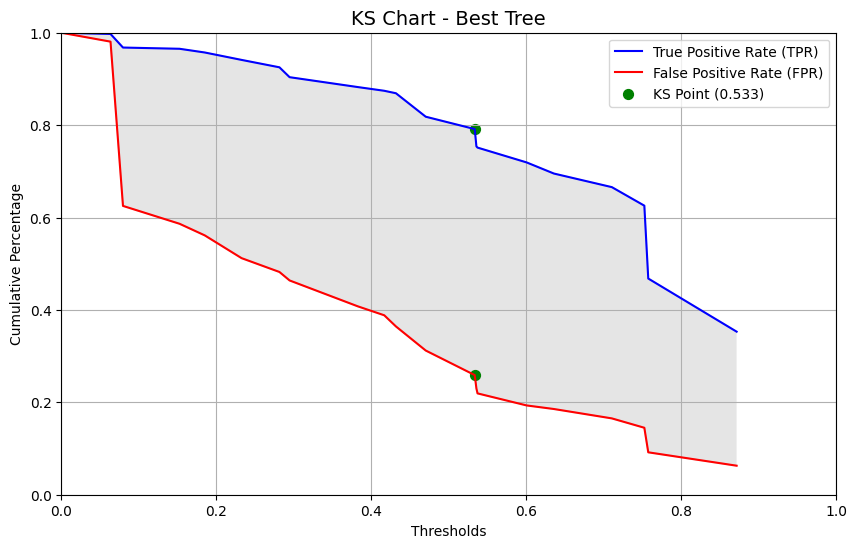

In [100]:
plot_ks_chart(y_test, y_prob_best, "Best Tree")

# **12. Plot The Best Model**

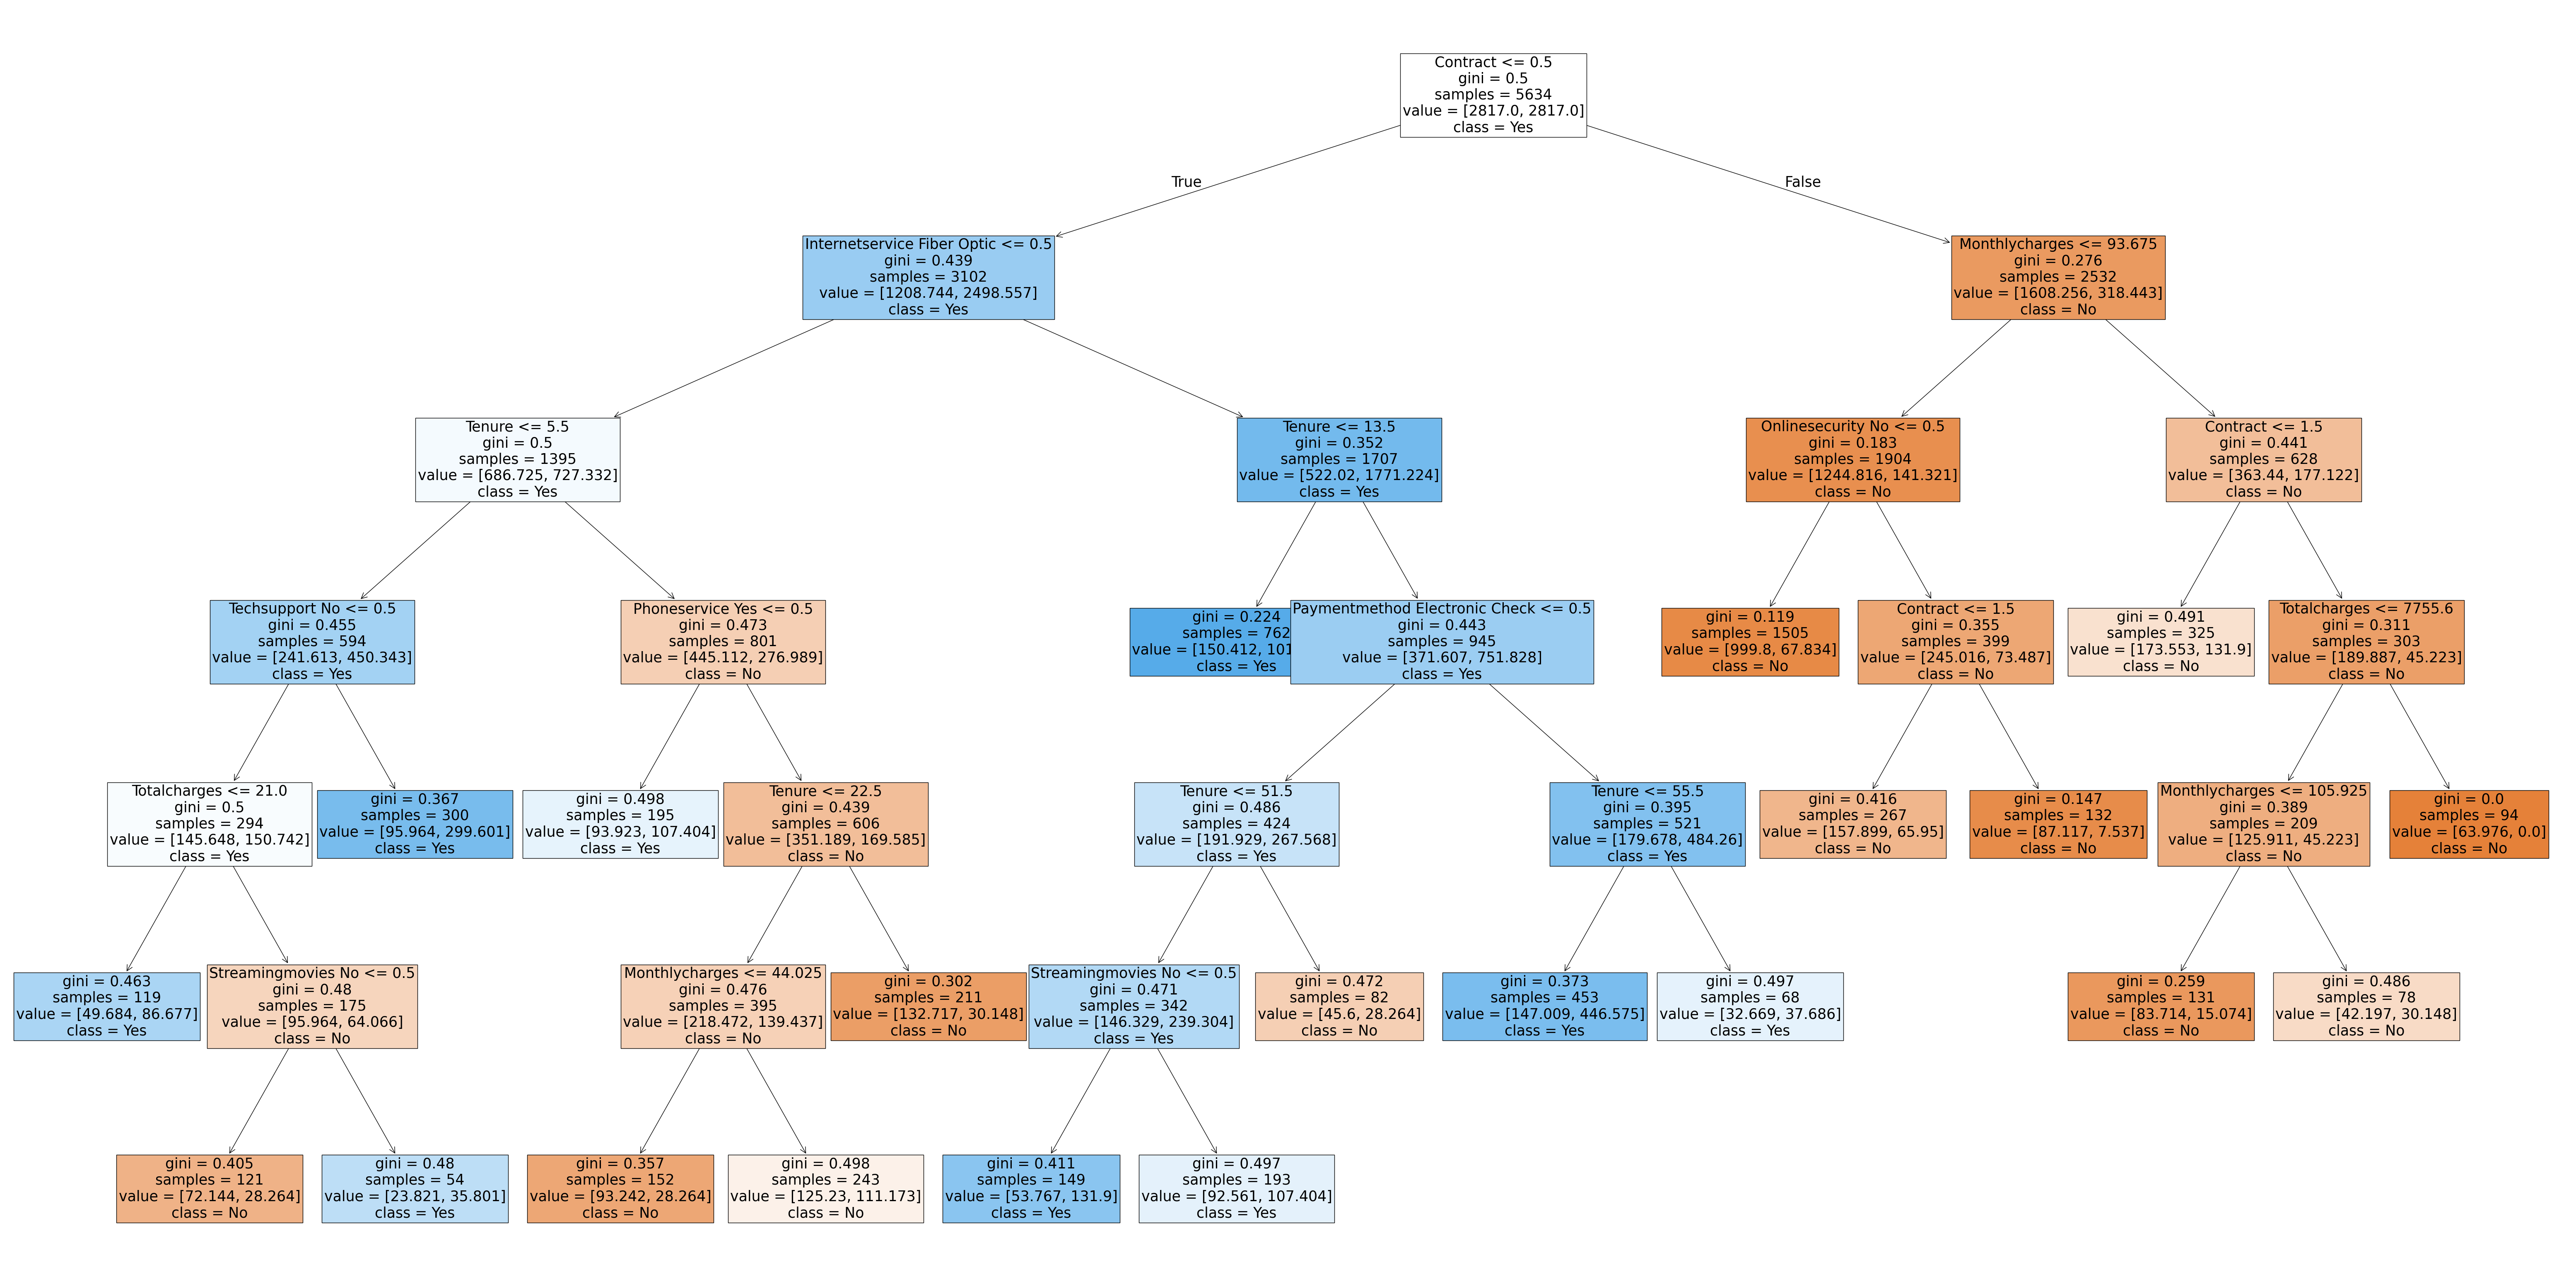

In [101]:
from sklearn.tree import plot_tree
plt.figure(figsize=(80,40))
plot_tree(best_tree, feature_names=feature_names, class_names=['No','Yes'], filled=True, fontsize=25)
plt.show()

# **13. Save The Best Model**

In [102]:
joblib.dump(best_tree, "best_tree_model.joblib")

['best_tree_model.joblib']